In [13]:
import numpy as np
import glob
import os
import colorsys

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [17]:
# Default plot parameters
plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 6),
    "font.size": 12,
    "font.family": "serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    # "axes.labelsize": 12,
    # "xtick.labelsize": 12,
    # "ytick.labelsize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    #"image.cmap": "viridis",
    "image.interpolation": "nearest",
    "axes.grid": False,
    "savefig.bbox": "tight",
})

# Open metadata

In [2]:
DIR = "/home/abernier/scratch/pulsar_data/search_results/"
FILES = glob.glob(os.path.join(DIR, "2022_CHIME_B2111+46_20220826T064420Z_rmstep*_metadata.npz"))

def load_metrics(file, param):
    param_value = int(file.split(f"{param}")[1].split("_")[0])  # Extract param value from filename
    metadata_dict = np.load(file, allow_pickle=True)['metadata'].item()
    
    return param_value, metadata_dict

In [3]:
param = 'rmstep'
results = [load_metrics(file, param) for file in FILES]
rmstep_list, dict_list = zip(*results)

# sort
sort_index = np.argsort(rmstep_list)
rmstep_list = np.array(rmstep_list)[sort_index]  # list of values ran for the chosen parameter 
dict_list = np.array(dict_list)[sort_index]

timing_dicts = [d['timings'] for d in dict_list]  # list of dicts of dicts
# Hierarchy:
# - every element in the list is a dict for different run ie param value
# - within those dicts, there are different dicts for each block of code. 
#    These have time information 'total', 'load_mask_normalize', 'rmsf_computation', 'rm_search', 'cross_correlation'

In [4]:
# Printing info
print(dict_list[0].keys())
print(timing_dicts[0].keys())
timing_dicts[0]['total']

dict_keys(['source', 'night', 'freq_bands', 'nsamples_per_chunk', 'stokes_time_sampling', 'nfiles', 'start_file_ind', 'phi_max', 'dphi_scaling', 'rfi_mean_threshold', 'rfi_std_threshold', 'rm_time_step', 'slurm_info', 'timings'])
dict_keys(['total', 'load_mask_normalize', 'rmsf_computation', 'rm_search', 'cross_correlation'])


{'wall_start': 265499.900690331,
 'cpu_start': 0.303902754,
 'mem_start_gb': 0.10223616,
 'wall_elapsed': 56.89556952897692,
 'cpu_elapsed': 56.490914026,
 'cpu_efficiency': 0.9928877502004645,
 'mem_end_gb': 4.751069184,
 'mem_peak_gb': 4.424777984619141}

# Functions

In [101]:
def scale_lightness(rgb, scale_l):
    # convert rgb to hls
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # manipulate h, l, s values and return as rgb
    return colorsys.hls_to_rgb(h, min(1, l * scale_l), s = s)


def get_colors(num_colors):
    tab = 'tab10' if num_colors<=10 else 'tab20'
    cmap = plt.colormaps[tab]
    
    colors_list = [cmap(i / num_colors) for i in range(num_colors)]
    colors_rgb = [colors.ColorConverter.to_rgb(c) for c in colors_list]
    
    colors_light = [scale_lightness(c, 1.1) for c in colors_rgb]
    colors_dark = [scale_lightness(c, 0.5) for c in colors_rgb]

    return colors_light, colors_dark


def plot_time_curves_by_block(x_arr, timing_dicts, x_label, fig_title=None, save_name=None,
                              save_loc='/scratch/abernier/rm-search-Bernier-2025/figures',
                              plot_total=True, plot_wall=True, plot_ylog=True):
    """
    Plot timing curves as a function of a tunable parameter for each code block.
    
    Parameters
    ----------
    timing_dicts : list of dict
        Collection of timing data, one entry per value of the tunable parameter.
    
        Structure:
        - Each element of the list corresponds to a single parameter value.
        - Each element is a dictionary whose keys are code blocks:
            'total' (optional), 'load_mask_normalize', 'rmsf_computation',
            'rm_search', 'cross_correlation'.
        - Each code block maps to another dictionary containing timing metrics:
            'wall_elapsed' : float
                Wall-clock elapsed time.
            'cpu_elapsed' : float
                CPU process time.
    save_loc : str
        Absolute path where to save the figure.
    """

    # -- Info for plotting --
    # Get code block labels and keys for timing dicts
    block_labels = ['Total', 'Mask RFI & Normalize', 'RMSF', 'RM Search', 'Cross-Correlation']
    block_labels = block_labels[1:] if not plot_total else block_labels  # remove 'Total'
    block_keys = list(timing_dicts[0].keys())[1:] if not plot_total else timing_dicts[0].keys()

    # Get colors
    num_colors = len(block_keys)
    colors_light, colors_dark = get_colors(num_colors)

    
    # -- Plot --
    fig, ax = plt.subplots(figsize=(8,5))
    fig.suptitle(fig_title)
    
    for i,code_block in enumerate(block_keys):
        # Get and plot data: wall and CPU times
        cpu_data = [t_dict[code_block]['cpu_elapsed'] for t_dict in timing_dicts]
        ax.plot(x_arr, cpu_data, c=colors_light[i], label=block_labels[i])
        
        if plot_wall:
            wall_data = [t_dict[code_block]['wall_elapsed'] for t_dict in timing_dicts]
            ax.plot(x_arr, wall_data,  c=colors_dark[i], ls=':')

    # Axes
    ax.set_xlabel(x_label)
    ax.set_ylabel('Time [s]')
    if plot_ylog:
        ax.set_yscale('log')

    
    # -- Legend handles --
    block_handles = [
        Patch(facecolor=colors_light[i], edgecolor='black', label=block_labels[i])
        for i in range(len(block_keys))
    ]  # color labels (code blocks)
    style_handles = [
        Line2D([0], [0], color='black', lw=2, label='CPU Time'),
        Line2D([0], [0], color='black', lw=2, linestyle=':', label='Wall Time')
    ]  # line style labels (time type)
    all_handles = (block_handles + style_handles)  # Combine handles
    
    # -- Legend --
    fig.canvas.draw()
    bbox = ax.get_position()
    legend_x = bbox.x1 + 0.02
    legend_y = bbox.y1  # top of graph
    
    fig.legend(
        handles=all_handles,
        loc='upper left',
        bbox_to_anchor=(legend_x, legend_y),
        frameon=True,
        handlelength=2.2,
        labelspacing=0.9
    )

    
    # -- Save figure --
    if save_name is not None:
        plt.savefig(f'{save_loc}/{save_name}', dpi=300)

    plt.show()


# CHANGE THIS TO BE PLOTTING A SINGLE VALUE FROM THE DICT
def plot_cpu_efficiency_by_block(x_arr, timing_dicts, x_label, fig_title=None, save_name=None,
                                 save_loc='/scratch/abernier/rm-search-Bernier-2025/figures',
                                 plot_total=True, plot_ylog=True):
    """
    Plot CPU efficiency curves as a function of a tunable parameter for each code block.
    
    Parameters
    ----------
    timing_dicts : list of dict
        Collection of timing data, one entry per value of the tunable parameter.
    
        Structure:
        - Each element of the list corresponds to a single parameter value.
        - Each element is a dictionary whose keys are code blocks:
            'total' (optional), 'load_mask_normalize', 'rmsf_computation',
            'rm_search', 'cross_correlation'.
        - Each code block maps to another dictionary containing timing metrics:
            'wall_elapsed' : float
                Wall-clock elapsed time.
            'cpu_elapsed' : float
                CPU process time.
    save_loc : str
        Absolute path where to save the figure.
    """

    # -- Info for plotting --
    # Get code block labels and keys for timing dicts
    block_labels = ['Total', 'Mask RFI & Normalize', 'RMSF', 'RM Search', 'Cross-Correlation']
    block_labels = block_labels[1:] if not plot_total else block_labels  # remove 'Total'
    block_keys = list(timing_dicts[0].keys())[1:] if not plot_total else timing_dicts[0].keys()

    # Get colors
    num_colors = len(block_keys)
    colors_light, colors_dark = get_colors(num_colors)

    
    # -- Plot --
    fig, ax = plt.subplots(figsize=(8,5))
    fig.suptitle(fig_title)

    # Get and plot data: wall and CPU times
    for i,code_block in enumerate(block_keys):
        cpu_data = [t_dict[code_block]['cpu_efficiency'] for t_dict in timing_dicts]
        ax.plot(x_arr, cpu_data, c=colors_light[i], label=block_labels[i])

    # Axes
    ax.set_xlabel(x_label)
    ax.set_ylabel('Time [s]')
    if plot_ylog:
        ax.set_yscale('log')


    # -- Legend --
    fig.canvas.draw()
    bbox = ax.get_position()
    legend_x = bbox.x1 + 0.02
    legend_y = bbox.y1  # top of graph
    
    fig.legend(
        title='CPU Efficiency',
        loc='upper left',
        bbox_to_anchor=(legend_x, legend_y),
        frameon=True,
        handlelength=2.2,
        labelspacing=0.9
    )

    
    # -- Save figure --
    if save_name is not None:
        plt.savefig(f'{save_loc}/{save_name}', dpi=300)

    plt.show()

# Plots

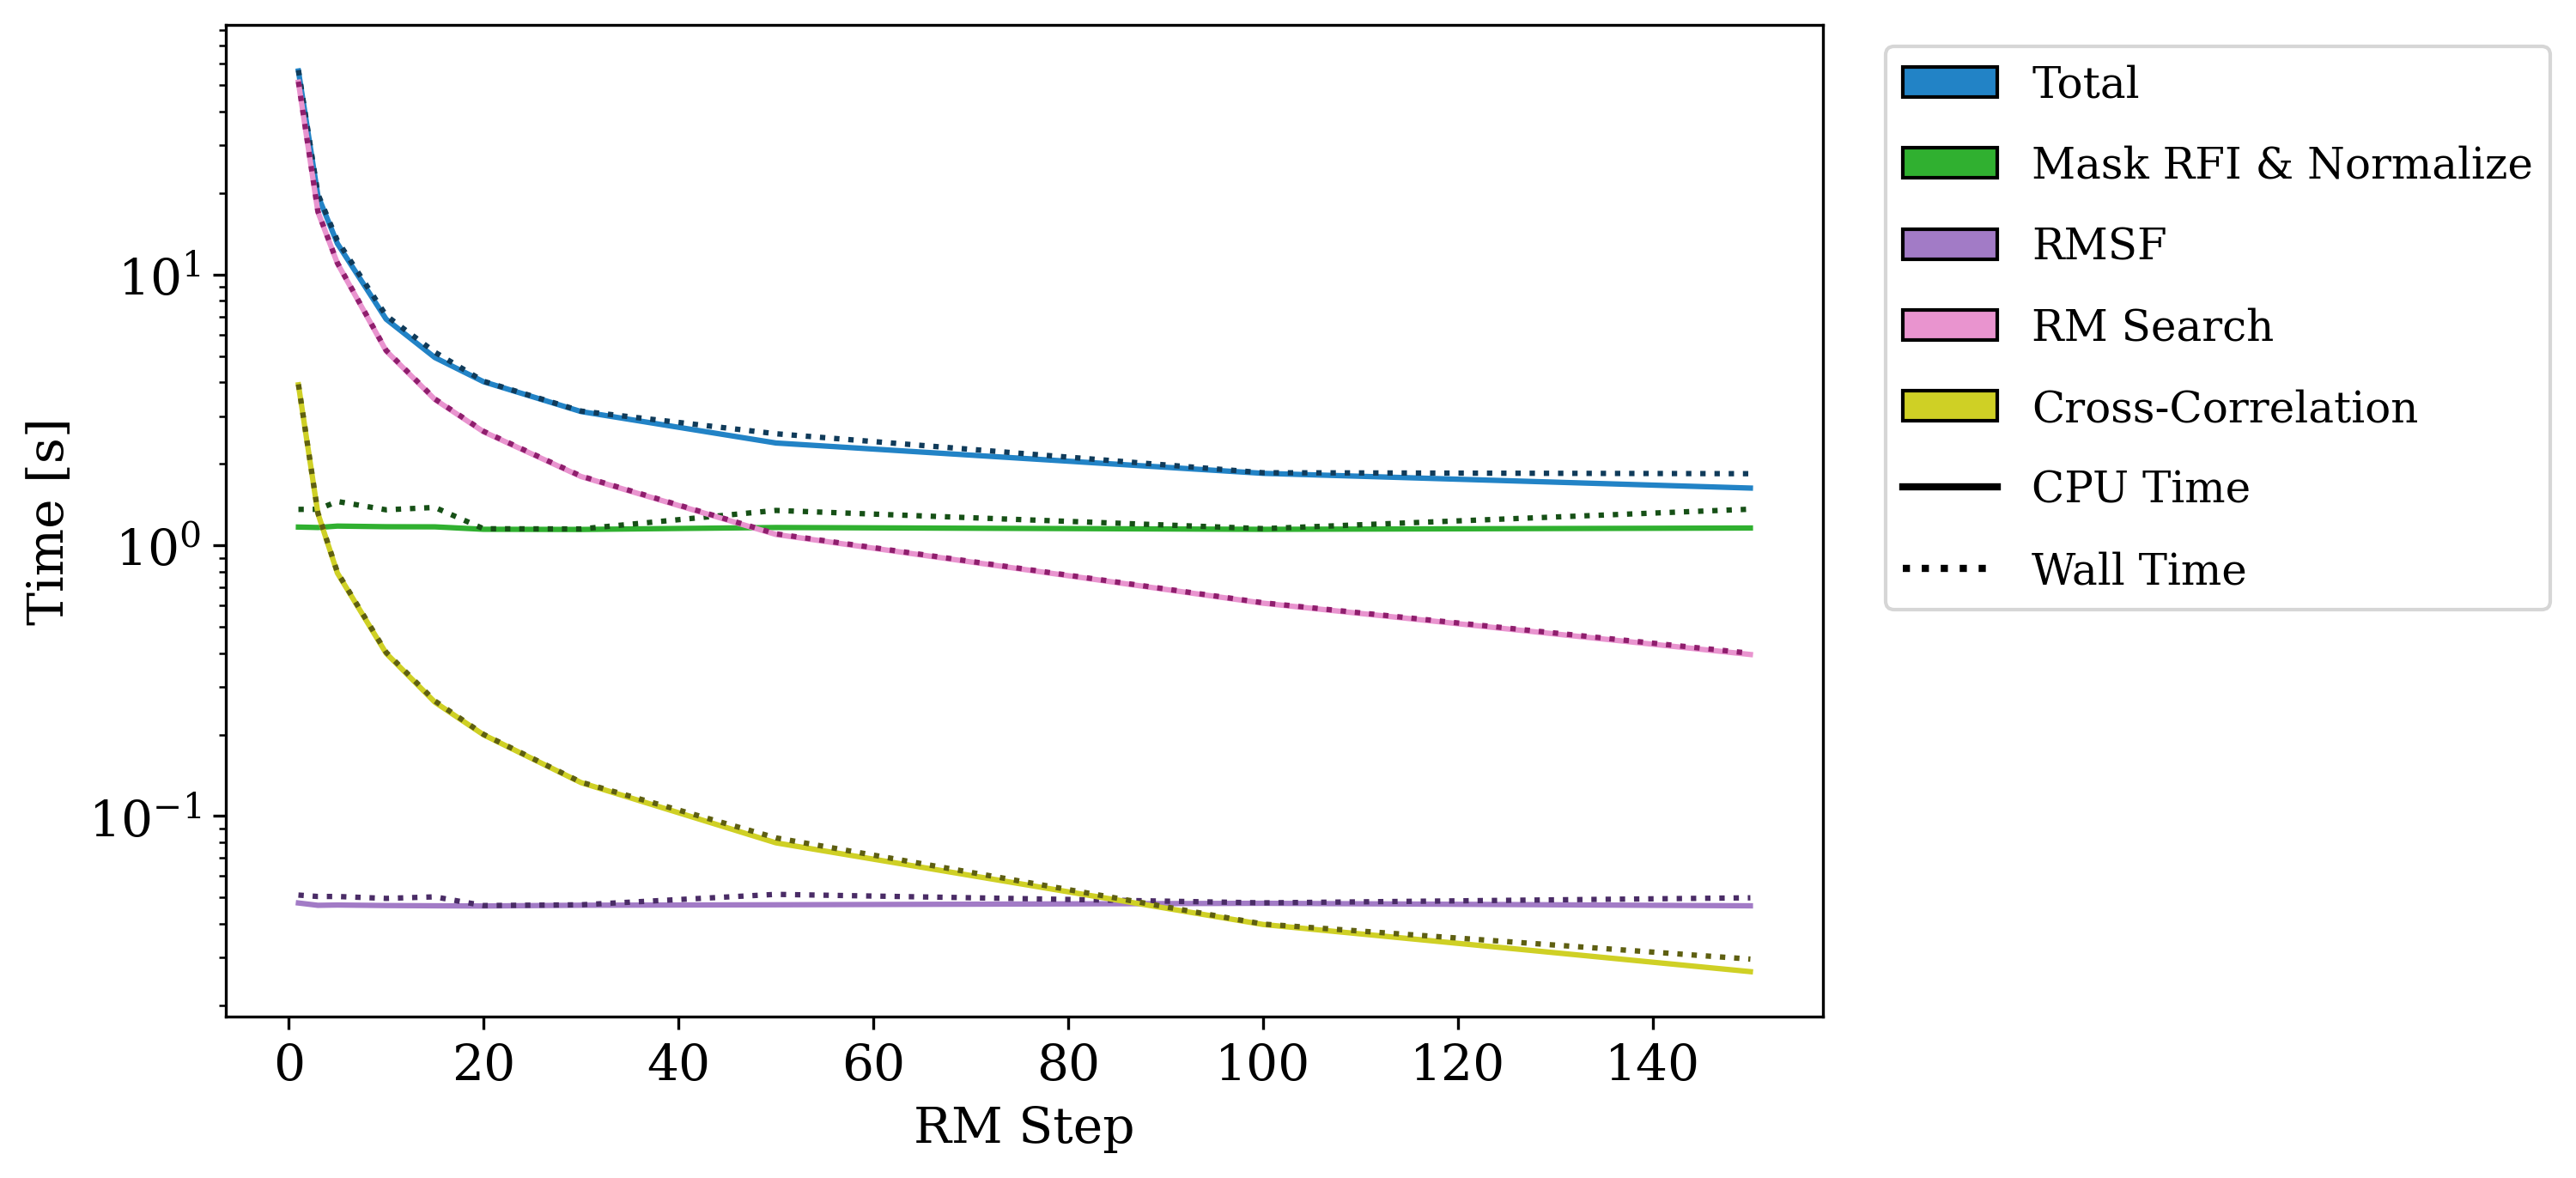

In [102]:
plot_time_curves_by_block(rmstep_list, timing_dicts, 'RM Step', 
                     fig_title=None, save_name='rmstep_timecurves',
                     plot_total=True, plot_wall=True, plot_ylog=True)

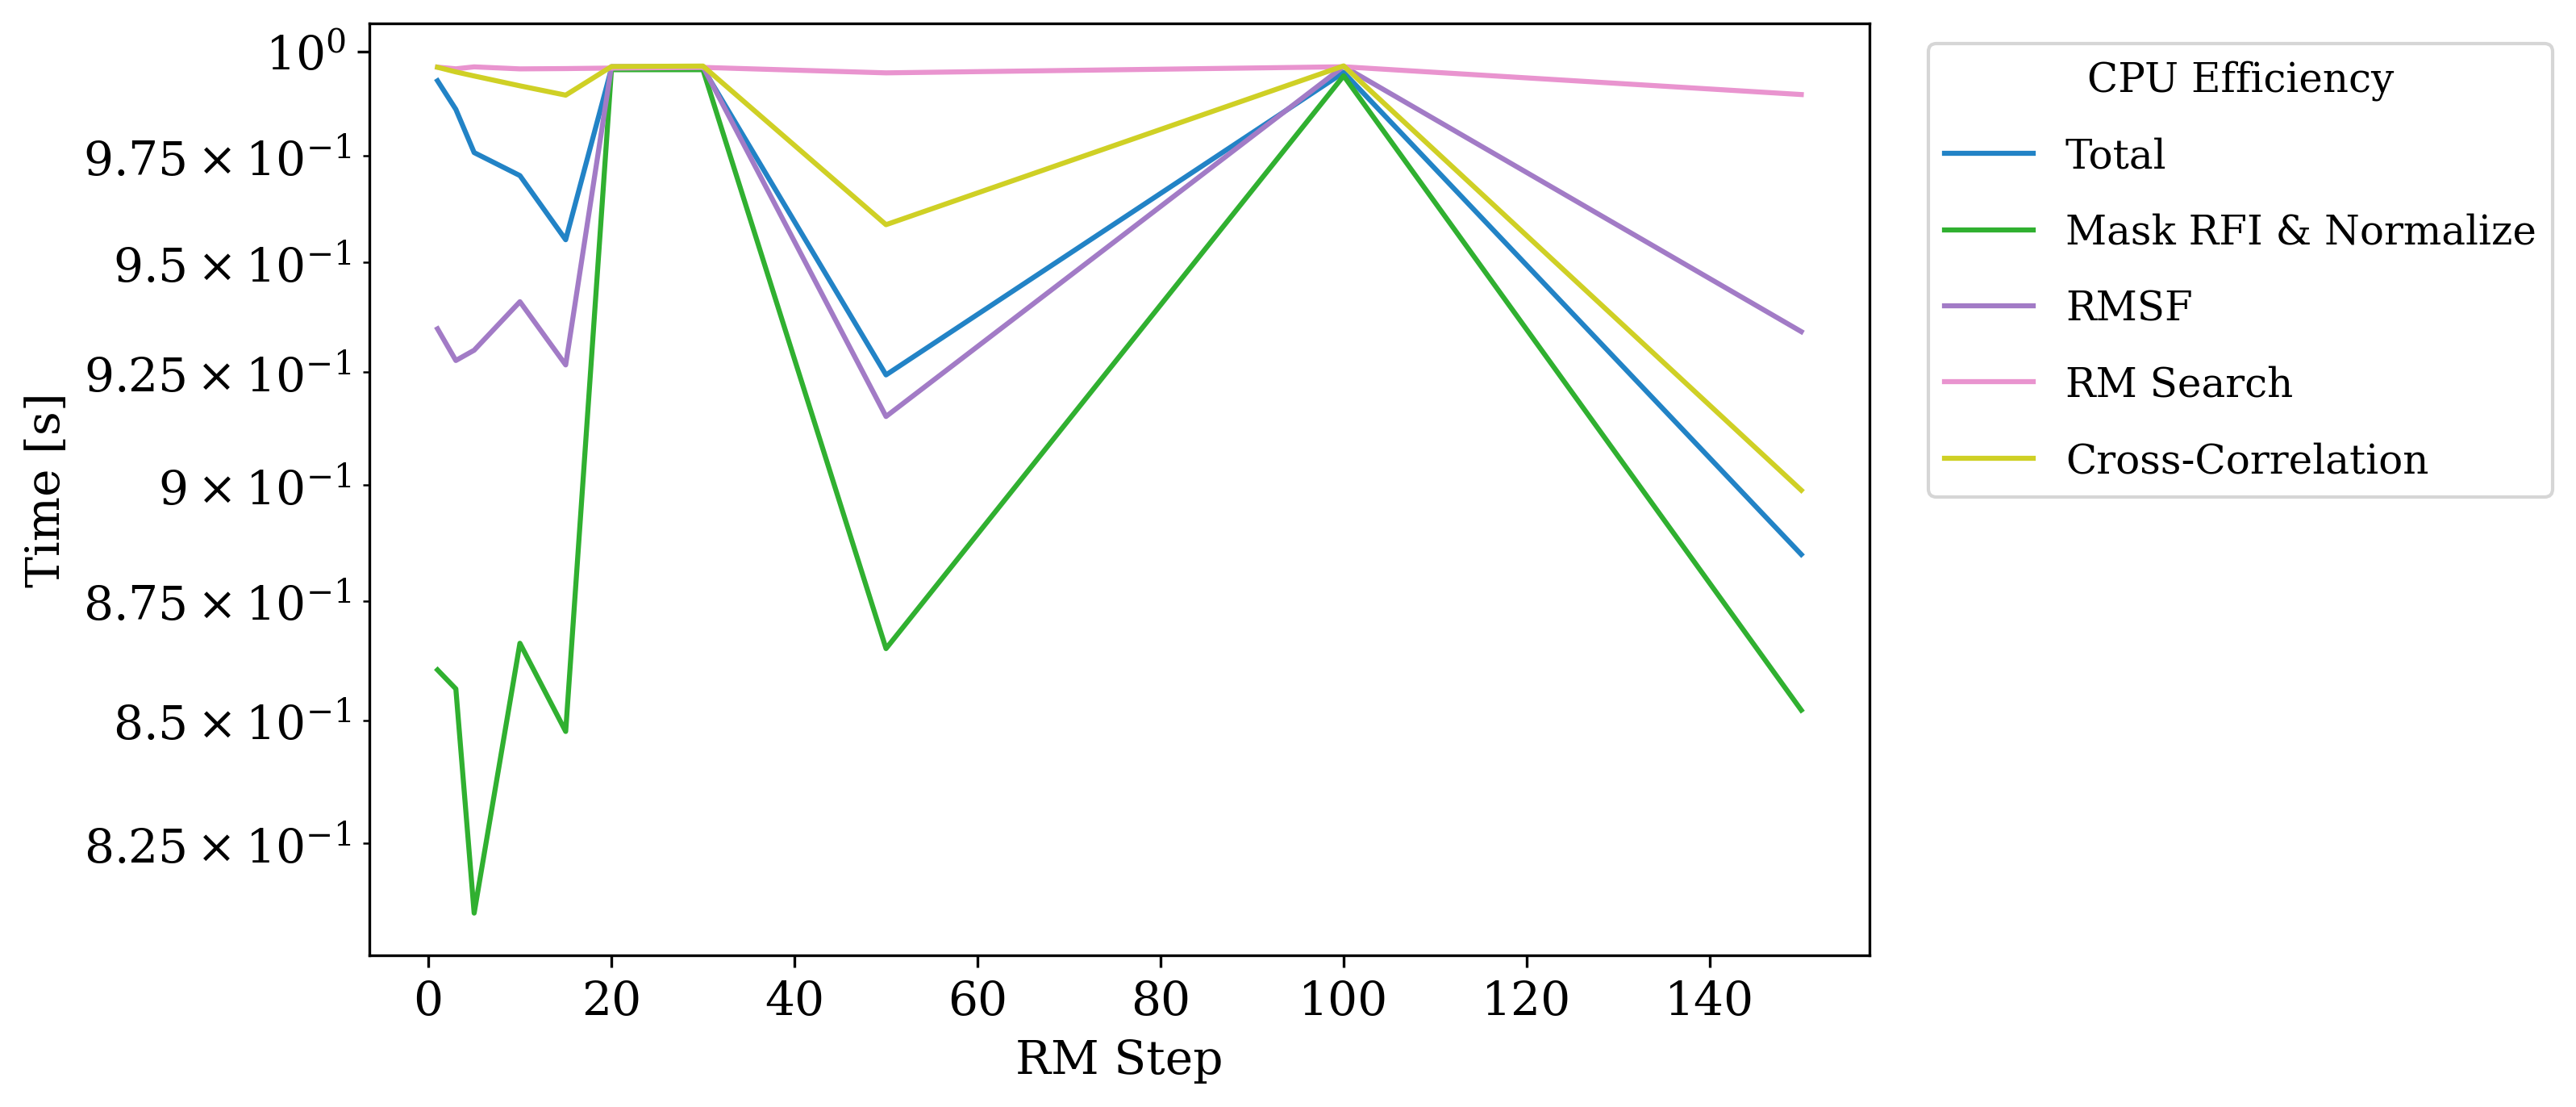

In [103]:
# cpu efficiency vs step, grouped by code block 
plot_cpu_efficiency_by_block(rmstep_list, timing_dicts, 'RM Step', 
                             fig_title=None, save_name='rmstep_efficiency',
                             plot_total=True, plot_ylog=True)